# 多维动态规划

[返回总目录](README.md) · [打开进度表](LeetCode%20Hot100与高频题目刷题清单与进度追踪表.xlsx)

主分类采用 [LeetCode Hot100 官网](https://leetcode.cn/studyplan/top-100-liked/)。扩展题紧邻相关题；解法标签可与主分类不同。原笔记中的局部编号保留，以本目录中的 LeetCode 题号为准。

## 本文目录

- [1770. 执行乘法运算的最大分数](#lc-1770) — 扩展题；已有详细笔记
- [5. 最长回文子串](#lc-5) — Hot100；已有详细笔记
- [516. 最长回文子序列](#lc-516) — 扩展题；已有详细笔记
- [647. 回文子串](#lc-647) — 扩展题；已有详细笔记
- [1039. 多边形三角剖分的最低得分](#lc-1039) — 扩展题；已有详细笔记
- [1143. 最长公共子序列](#lc-1143) — Hot100；已有详细笔记
- [712. 两个字符串的最小ASCII删除和](#lc-712) — 扩展题；已有详细笔记
- [72. 编辑距离](#lc-72) — Hot100；已有详细笔记

基础模板：[动态规划基础](15_动态规划.ipynb#基础与模板)。


## lc-1770

**1770. 执行乘法运算的最大分数**

多维动态规划 / 多维状态与路径 · 扩展题 · 困难

[官网题目](https://leetcode.cn/problems/maximum-score-from-performing-multiplication-operations/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：多维状态与路径。

相关 Hot100 题：[64. 最小路径和（本地未收录）](https://leetcode.cn/problems/minimum-path-sum/)。

归类说明：按操作次数和左侧选择数建二维状态，属于多维DP扩展。

表格摘要：这个题最难的点在于f数组的理解，f[i][j]计算的是剩余操作的最大分数，也就是从第i+1步操作到第m步的最大分数，而j代表着已经选取了j个左侧的值，同时也指明了当前左指针正指向j这个元素，选取的值不论左右，是不会计入到…


**_#17.乘法运算的最大分数_**

这个题最难的点在于f数组的理解，f[i][j]计算的是剩余操作的最大分数，也就是从第i+1步操作到第m步的最大分数，而j代表着已经选取了j个左侧的值，同时也指明了当前左指针正指向j这个元素，选取的值不论左右，是不会计入到分数计算里去的，而从f[i+1]到f[i]，剩余的操作数增加，因此对于这一步操作而言，有两种可能，一是将当前左边的值加入到分数计算中，因此选取的左边的元素值-1，反之选取的右边元素的值减去1.

In [ ]:
class Solution:
    def maximumScore(self, nums, multipliers) -> int:
        m = len(multipliers)
        # @cache
        # def dfs(i,j,x):
        #     if x == m:
        #         return 0
        #     y = multipliers[x]
        #     return max(dfs(i,j-1,x+1) + nums[j] * y,dfs(i+1,j,x+1) + nums[i] * y)

        m, n = len(multipliers), len(nums)
        f = [[0] * (m+1) for _ in range(m+1)]#f[m][]代表的是初始状态，此时操作数为m+1,不合法，因此最大分数都为0.
        for i in range(m-1, -1, -1):
            for left in range(i+1):
                f[i][left] = max(multipliers[i] * nums[left] + f[i+1][left+1], multipliers[i] * nums[n-1-i+left] + f[i+1][left])
        return f[0][0]
#反向DP:f[i][j]的含义是从第i次操作开始，左边已经取了left个，能获得的最大分数
#正向DP:f[i][j]的含义是前i次操作，左边取了left个，获得的最大分数
#这个题中，f[i][j]表示：当我们正要执行第 i+1 次操作（对应使用乘数 multipliers[i]）时，且在执行这次操作前，已经从 nums 的左端一共取了 j 个元素（右端则取了 i - j 个元素）；在这个状态下，从「第 i 次操作」到「最后一次操作（第 m-1 次）」的所有剩余操作中，能获得的最大分数，计算的是排除这部分取得元素后能获取的最大分数

## lc-5

**5. 最长回文子串**

多维动态规划 / 回文与区间DP · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/longest-palindromic-substring/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：中心扩展 / 多维动态规划。

表格摘要：使用这种方法通过一次循环就实现了对每个位置的奇回文串与偶回文串的检查


**_#12.最长回文子串_**
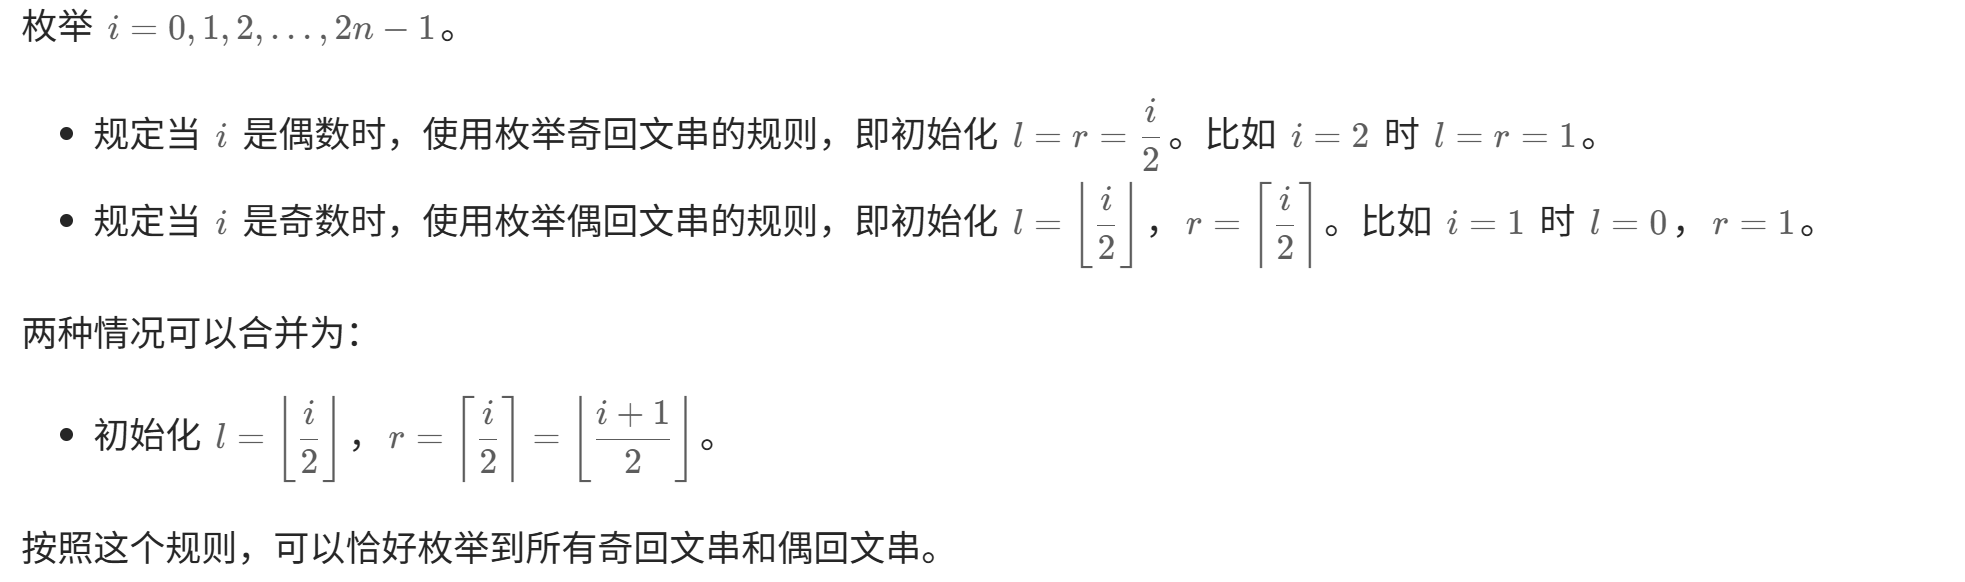
使用这种方法通过一次循环就实现了对每个位置的奇回文串与偶回文串的检查

In [ ]:
class Solution:
    def longestPalindrome(self, s: str) -> str:
        n = len(s)
        ans_left = ans_right = 0
        for i in range(2 * n - 1):#这里为2*n-1是因为首先l与r都经过了除2的操作，为了使所有的字符都能够作为回文串的中心，因此要乘2，同时，如果是2*n的话存在r越界的风险。
            l = i // 2
            r = (i + 1) // 2
            while l >= 0 and r < len(s) and s[l] == s[r]:
                l -= 1
                r += 1
            if r - l - 1 >= ans_right - ans_left:#因为左闭右开，所以字符长度right - left即可
                ans_left,ans_right = l+1,r#左闭右开区间，为了匹配后续字符的输出

        return s[ans_left:ans_right]

## lc-516

**516. 最长回文子序列**

多维动态规划 / 回文与区间DP · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/longest-palindromic-subsequence/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：回文与区间DP。

相关 Hot100 题：[5. 最长回文子串](16_多维动态规划.ipynb#lc-5)。

归类说明：从回文子串扩展到回文子序列。

表格摘要：区间DP：f[i][j]表示s[i..j]的最长回文子序列；s[i]==s[j]则+2，否则取max(去左,去右)


**_#9.最长回文子序列（区间dp问题）_**

对于区间dp问题而言，空间上一般不能简化，二维是必须的
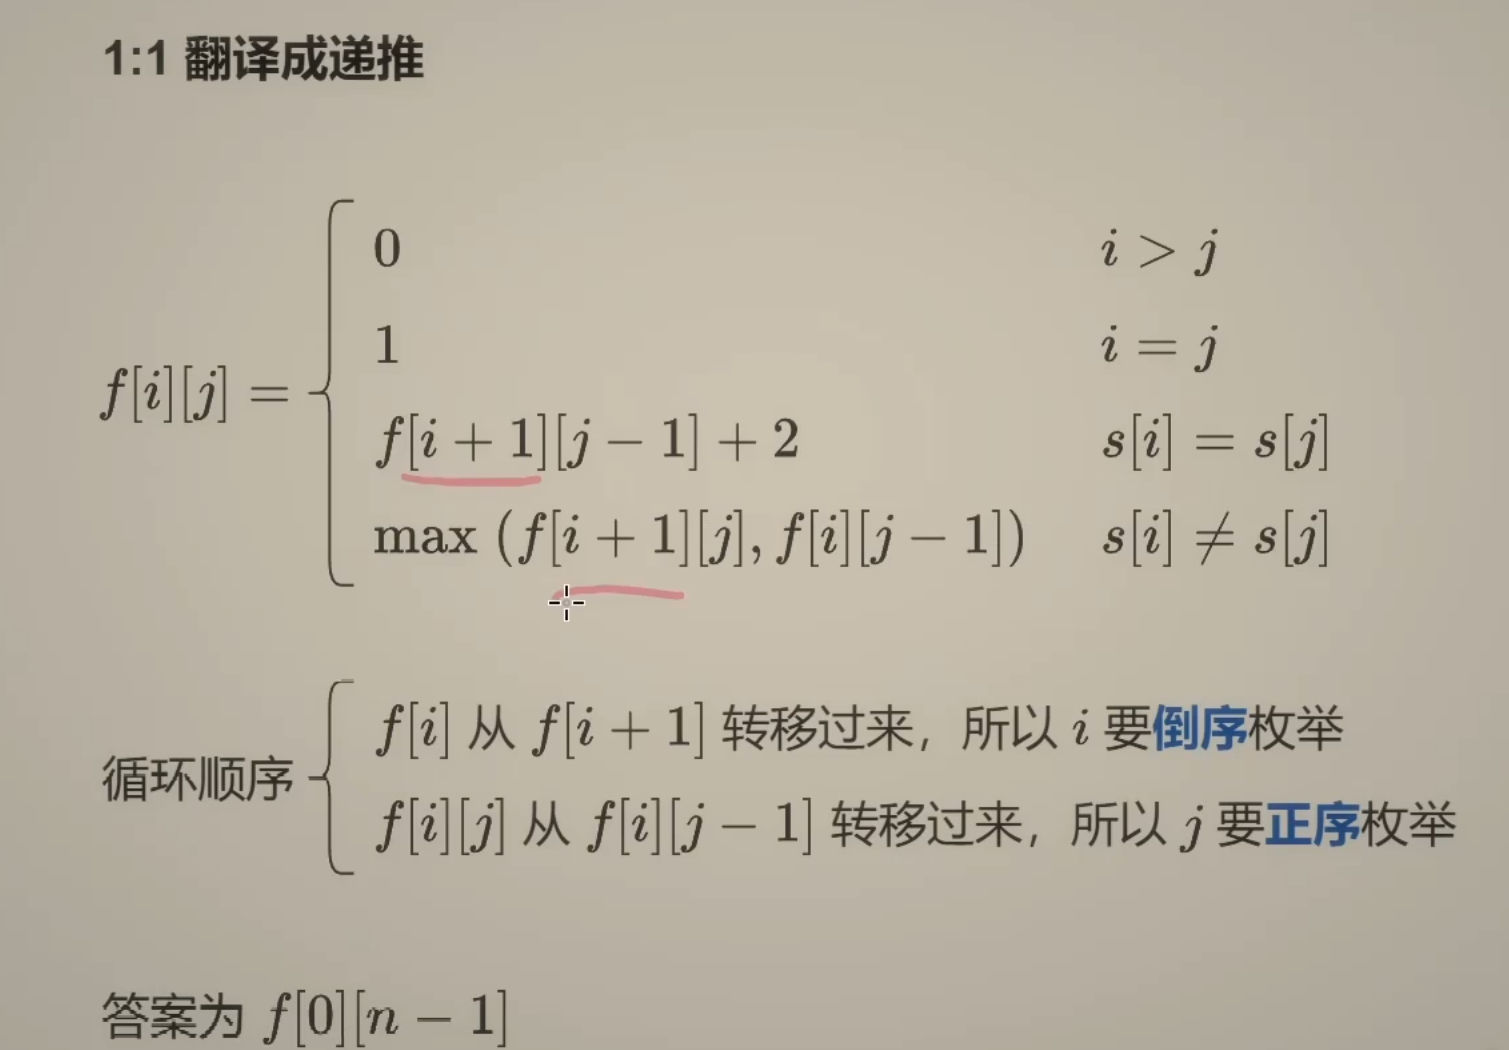

In [ ]:
#1，递归写法
#时间复杂度为0(n*2)：因为left与right都有n个取值，所以有n*2个状态，每个状态只需计算一次。
# @cache
        # def dfs(left,right):
        #     if left == right:
        #         return 1
        #     elif left > right:
        #         return 0
        #     elif s[left] == s[right]:
        #         return dfs(left+1,right-1) + 2
        #     else:
        #         return max(dfs(left,right-1),dfs(left+1,right))# 不匹配时如果舍弃left，就取left+1，如果舍弃right，就取right-1.

        # left,right = 0,len(s)-1
        # return dfs(left,right)

#2.动态规划写法：
#时间复杂度：0(n*2)
#空间复杂度：0(n*2)

        n = len(s)
        f = [[0] * n for _ in range(n)]

        num = 0
        for left in range(n-1,-1,-1):
            f[left][left] = 1
            for right in range(left+1,n):
                if s[left] == s[right]:
                    f[left][right] = f[left+1][right-1] + 2
                else:
                    f[left][right] = max(f[left+1][right],f[left][right-1])
        return f[0][n-1]

## lc-647

**647. 回文子串**

多维动态规划 / 回文与区间DP · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/palindromic-substrings/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：回文与区间DP。

相关 Hot100 题：[5. 最长回文子串](16_多维动态规划.ipynb#lc-5)。

归类说明：从最长回文子串扩展到回文子串计数。

表格摘要：是用动态规划思路解答这个问题的关键在于想清楚dp数组的含义，[i,j]的含义不是从i到j的字符字串中含有多少回文子串，而是判断这个子串是不是一个回文串，因此dp数组有True与False构成，通过统计True的数量来判断…


**_#11.回文子串：_**

是用动态规划思路解答这个问题的关键在于想清楚dp数组的含义，[i,j]的含义不是从i到j的字符字串中含有多少回文子串，而是判断这个子串是不是一个回文串，因此dp数组有True与False构成，通过统计True的数量来判断整个字符串中回文串的数量。

In [ ]:
#时间复杂度：0(n*2)
#空间复杂度：O(n*2)
class Solution:
    def countSubstrings(self, s: str) -> int:
        n = len(s)
        f = [[False] * n for _ in range(n)]
        res = 0
        for i in range(n-1,-1,-1):
            for j in range(i,n):
                if s[i] == s[j]:
                    if j - i <= 1:
                        f[i][j] = True
                        res += 1
                    else:
                        if f[i + 1][j - 1]:
                            f[i][j] = True
                            res += 1
        return res

## lc-1039

**1039. 多边形三角剖分的最低得分**

多维动态规划 / 回文与区间DP · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/minimum-score-triangulation-of-polygon/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：回文与区间DP。

相关 Hot100 题：[5. 最长回文子串](16_多维动态规划.ipynb#lc-5)。

归类说明：与回文区间DP共享区间状态；在区间内枚举分割点。

表格摘要：回溯三问： 1.当前操作：在(i，j)的范围内枚举一个数k 2.子问题：求解(i,j)的最低得分 3.下一个子问题：求解(i,k)与(k,j)的最低得分


**_#10.多边形三角剖分的最低得分(区间dp问题)_**

    回溯三问：
    1.当前操作：在(i，j)的范围内枚举一个数k
    2.子问题：求解(i,j)的最低得分
    3.下一个子问题：求解(i,k)与(k,j)的最低得分

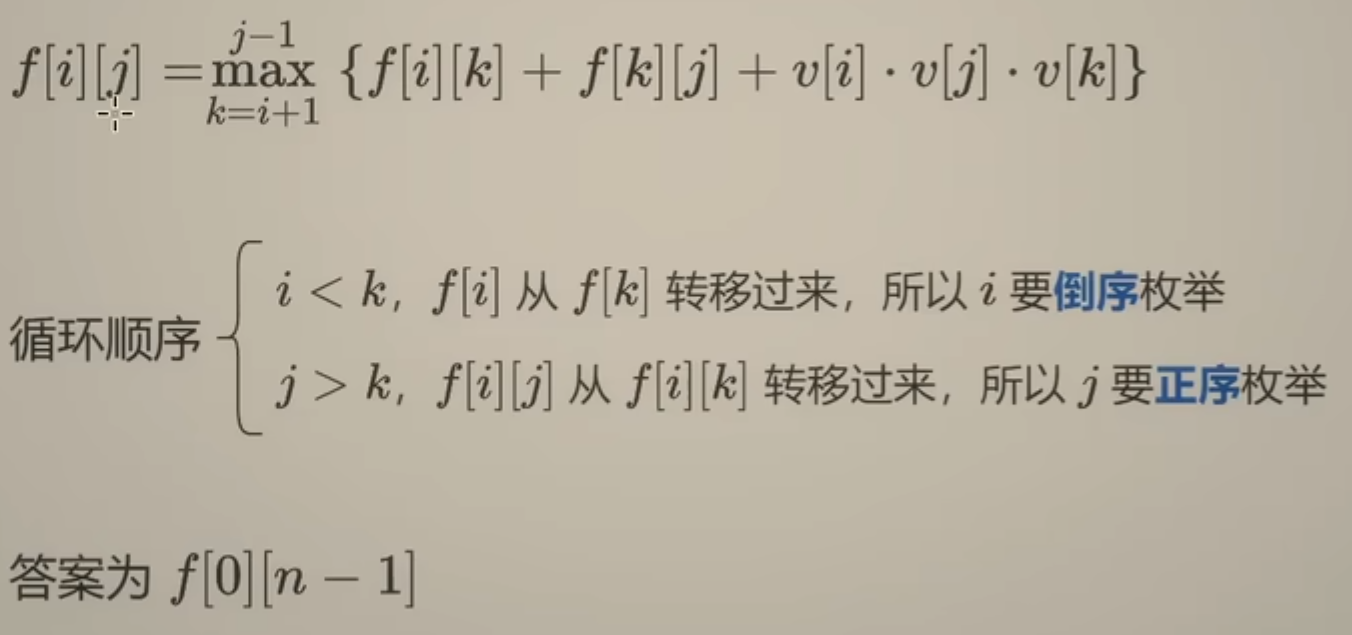

In [ ]:
class Solution:
    def minScoreTriangulation(self, values) -> int:
        n = len(values)
        # @cache
        # def dfs(i,j):
        #     if i + 1 == j :#因为我们枚举是在（i,j）的开区间上进行的，当满足这个条件的时候意味着区间内没有值了，结束递归。
        #         return 0
        #     min_num = inf
        #     for x in range(i+1,j):#i与j不要选，枚举x
        #         curr_num = values[i] * values[j] * values[x]
        #         min_num = min(curr_num+dfs(i,x)+dfs(x,j),min_num)
        #     return min_num
        # return dfs(0,n-1)

        f = [[0] * n for _ in range(n)]
        for i in range(n-3,-1,-1):#从n-3开始时才能保证j有意义
            for j in range(i+2,n):#当j=i+1时，开区间内没有值，所以从i+2开始
                res = inf#这句话要放在下面的循环外面，这样才是枚举k时的最小值，否则的话只是将当前的k值与inf进行比较
                for k in range(i+1,j):
                    curr_num = values[i] * values[j] * values[k]
                    res = min(curr_num+f[i][k]+f[k][j],res)
                f[i][j] = res
        return f[0][n-1]

## lc-1143

**1143. 最长公共子序列**

多维动态规划 / 双序列 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/longest-common-subsequence/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：字符串 / 动态规划。

表格摘要：二维DP：text1[i]==text2[j]则f[i][j]=f[i-1][j-1]+1，否则取max(f[i-1][j], f[i][j-1])


**_#5.线性dp问题_**

**_最长公共子序列的长度（lcs)_**
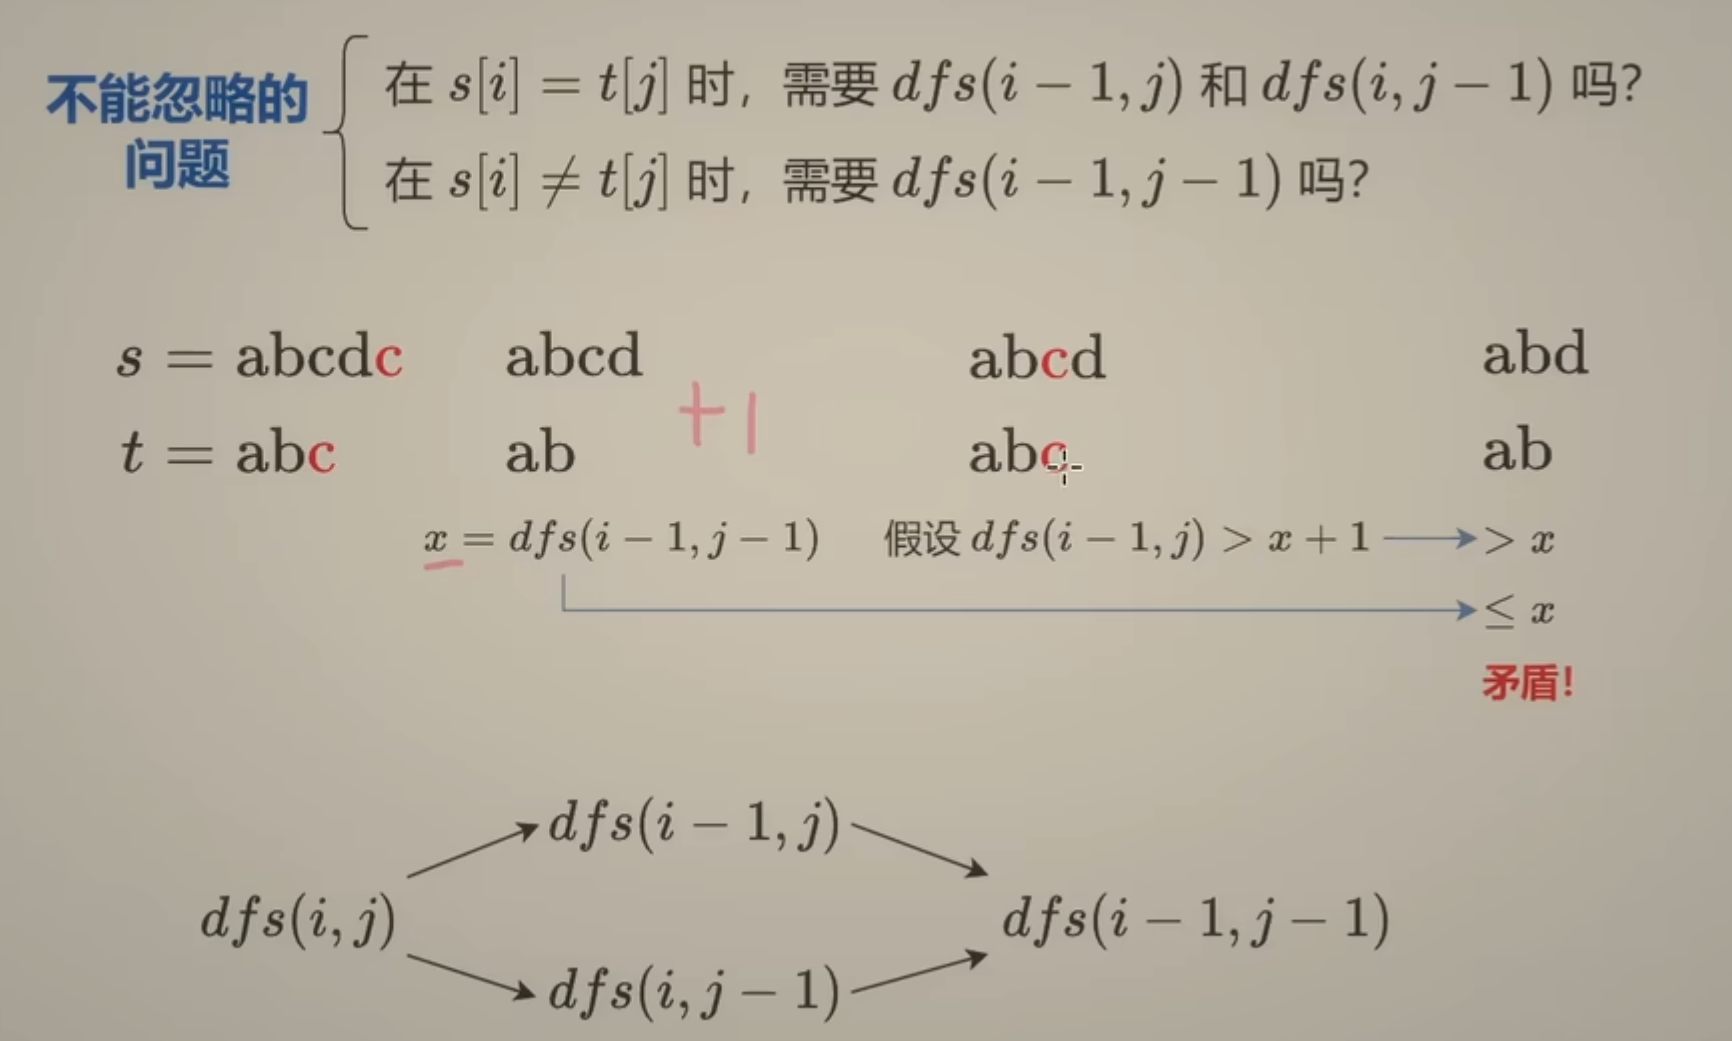
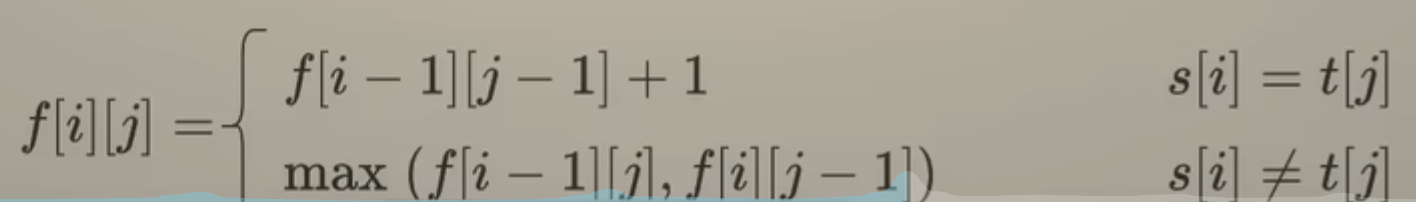

#当两个序列都没有重复元素时，将LCS问题转化为LIS问题：

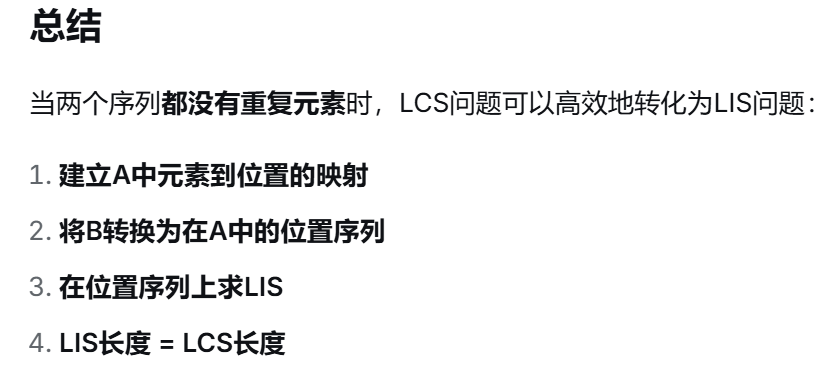

    from bisect import bisect_left

    def lcs_via_lis(A, B):
        """
        将LCS问题转化为LIS问题求解（要求A和B都没有重复元素）
        时间复杂度：O(n log n)
        """
        if not A or not B:
            return 0

        # 步骤1：建立A中元素到位置的映射（位置从1开始）
        pos_map = {}
        for i, num in enumerate(A):
            pos_map[num] = i + 1  # +1避免0，让位置从1开始

        # 步骤2：将B转换为在A中的位置序列（过滤掉A中没有的元素）
        pos_seq = []
        for num in B:
            if num in pos_map:
                pos_seq.append(pos_map[num])

        # 步骤3：在位置序列上求LIS
        g = []#数组g是严格递增的，又因为pos_seq存储的是A与B的公共元素在A中的位置索引，因此这些元素在A中的位置是严格递增的
        for x in pos_seq:#遍历的是A与B的公共元素，这个循环保证了元素在B中的位置是严格递增的
            j = bisect_left(g, x)
            if j == len(g):
                g.append(x)
            else:
                g[j] = x

        return len(g)


In [ ]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        m = len(text1)
        n = len(text2)
        f = [[0]*(n+1) for _ in range(m+1)]#f[i][j]的含义是从text1的前i个字符与text2的前j个字符对比，最长公共子序列的长度

        for i,x in enumerate(text1):
            for j,y in enumerate(text2):
                if x == y:
                    f[i+1][j+1] = 1 + f[i][j]
                else:
                    f[i+1][j+1] = max(f[i][j+1],f[i+1][j])
        return f[m][n]

In [ ]:
#使用两个一维数组的版本
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        n = len(text2)
        f1 = [0 for _ in range(n+1)]#左边的值
        f2 = [0 for _ in range(n+1)]#左上以及上边的值

        for i,x in enumerate(text1):
            for j,y in enumerate(text2):
                f1[j+1] = f2[j] + 1 if x==y else max(f1[j],f2[j+1])
            f2 = f1[:]#f2是上一行的值，因此在这一行更新完以后即将更新新的一行的时候将当前的值赋给上一行
        return f1[n]

In [1]:
#使用一个一维数组以及一个临时变量的版本
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        n = len(text2)
        f = [0 for _ in range(n+1)]

        for i,x in enumerate(text1):
            pre = 0#代表之前左上角的值，对于pre的设置要特别注意，对于lcs问题而言，每次进入外层循环的时候用字符串一的前i-1个元素匹配字符串二的前0个字符的值为0，而对于一些其他的问题，pre的值不一定等于0
            f[0] = 0 #f[0]的设置也很关键，因为我们在遍历的过程中不会遍历到第一个元素，因此需要我们手动设置f[0]的值，而f[0]的值不一定都是0，这一点要特别注意
            for j,y in enumerate(text2):
                temp = f[j+1]#之前上方的值
                f[j+1] = pre + 1 if x==y else max(f[j],temp)
                pre = temp#在计算完j+1处的值后，下一步就要计算j+2处的值，此时temp就从以前上方的值变为了下一个数的左上方的值
        return f[n]

## lc-712

**712. 两个字符串的最小ASCII删除和**

多维动态规划 / 双序列 · 扩展题 · 中等

[官网题目](https://leetcode.cn/problems/minimum-ascii-delete-sum-for-two-strings/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：双序列。

相关 Hot100 题：[1143. 最长公共子序列](16_多维动态规划.ipynb#lc-1143) · [72. 编辑距离](16_多维动态规划.ipynb#lc-72)。

归类说明：把双序列匹配扩展为字符删除代价。

表格摘要：LCS变式：总ASCII和-2×LCS；或直接DP，两字符不同时取删s1[i]或删s2[j]的较小值


In [ ]:
class Solution:
    def minimumDeleteSum(self, s1: str, s2: str) -> int:
        n = len(s2)
        f = [0]* (n+1)
        for i,x in enumerate(s2):
            f[i+1] = f[i] + ord(x)

        for i,x in enumerate(s1):
            pre = f[0]
            f[0] += ord(x)#这两行的设置尤为关键
            for j, y in enumerate(s2):
                temp = f[j+1]#！！！！！！！！！！
                if x == y:
                    f[j+1] = pre
                else:
                    f[j+1] = min(f[j]+ord(y),temp+ord(x))
                pre = temp#！！！！！！！！！！！
        return f[n]

## lc-72

**72. 编辑距离**

多维动态规划 / 双序列 · Hot100 · 中等

[官网题目](https://leetcode.cn/problems/edit-distance/) · [返回本文目录](#本文目录) · [总目录](README.md)

笔记情况：已有详细笔记。解法标签：字符串 / 动态规划。

表格摘要：DP：f[i][j]编辑距离；末尾字符相同直接继承，不同则取增/删/改三者最小值+1


**_#6.编辑距离_**

In [ ]:
#递归以及两个一维数组写法
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:

        # @cache
        # def dfs(i,j):
        #     if j < 0:
        #         return i+1#要删除
        #     if i < 0:
        #         return j+1#要插入
        #     elif word1[i]==word2[j]:
        #         return dfs(i-1,j-1)
        #     else:
        #         return min(dfs(i-1,j-1)+1,dfs(i-1,j)+1,dfs(i,j-1)+1)

        # m = len(word1)
        # n = len(word2)
        # return dfs(m-1,n-1)

        n = len(word2)

        f1 = [i for i in range(n+1)] #f1数组的含义word1的前i-1个字符与word2的前j个字符匹配时所需的操作数，是先前的值
        f2 = [0] * (n+1)#f2数组的含义是word2的前i个字符与与word2的前j个字符匹配时所需的操作数，是现在的值

        for i,x in enumerate(word1):
            f2[0] = i + 1
            for j,y in enumerate(word2):
                if x==y:
                    f2[j+1] = f1[j]#左上角
                else:
                    f2[j+1] = min(f1[j]+1,f2[j]+1,f1[j+1]+1)#其中，f1[j]+1代表的是替换操作，f2[j]+1代表的是插入操作，而f1[j+1]+1代表的是删除操作
            f1 = f2[:]
        return f1[n]

In [ ]:
#使用一个列表与临时变量的写法
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:
        n = len(word2)

        f1 = [i for i in range(n+1)] #最开始时word1的前0个字符与word2去匹配

        for i,x in enumerate(word1):
            pre = i #左上角的值
            f1[0] = i + 1#这个值需要自行设置，因为遍历是从1开始的
            for j,y in enumerate(word2):
                temp = f1[j+1]#修改之前的上方的值
                if x==y:
                    f1[j+1] = pre#左上角
                else:
                    f1[j+1] = min(f1[j]+1,pre+1,temp+1)
                pre = temp

        return f1[n]